# Neural Network Function Approximation

This notebook is the third stop in the `01_foundations_extensions` research track.

It closes the triangle opened by the first two notebooks. Notebook 01 made derivatives exact via autograd, and notebook 02 made the *spectral content* of a target explicit via Chebyshev analysis. Here we ask the natural question for physics-informed learning: when a neural network is the function approximator, which spectral modes does gradient descent learn, and in what order?

The notebook is intentionally not a survey of approximation theory. It is a small, reproducible empirical study that reproduces the single most useful mental model for scientific ML practitioners: **spectral bias** — the low-frequency first, high-frequency later behaviour of MLP training — together with the standard fix (Fourier feature encodings).

## Notebook Contract

- **Status:** research-executable
- **Lane:** `10_Research_Tracks/01_foundations_extensions`
- **Research question:** on a target with explicit low- and high-frequency content, do MLPs fit the low frequencies first, and do Fourier feature encodings recover the high-frequency content faster?
- **Canonical problem:** regression fit of $u^*(x) = \sin(2\pi x) + 0.30\,\sin(20\pi x)$ on $[0, 1]$ with a small Tanh MLP, full-batch Adam, no tricks.
- **Prerequisites:** autodiff notebook (`01_automatic_differentiation_for_physics.ipynb`), spectral notebook (`02_spectral_methods_and_fourier_analysis.ipynb`).
- **Deliverable:** three recycled experiments: (1) a width sweep that shows the practical limit of universal approximation, (2) a per-frequency training-time error that reproduces spectral bias, (3) a Fourier feature encoding that closes the high-frequency gap and reproduces the Tancik et al. result.
- **Estimated runtime:** under 2 minutes on CPU.
- **References:**
  - Cybenko. *Approximation by Superpositions of a Sigmoidal Function* (Math. Control Signals, 1989).
  - Rahaman et al. *On the Spectral Bias of Neural Networks* (ICML, 2019).
  - Rahimi & Recht. *Random Features for Large-Scale Kernel Machines* (NeurIPS, 2007).
  - Tancik et al. *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains* (NeurIPS, 2020).
- **Next notebooks:** the spectral-bias lens reappears in `01_Core_Path/06_multi_scale_pinns.ipynb` and in `01_Core_Path/09_fourier_neural_operator.ipynb`.

## Why This Notebook Exists

PINNs and operator learners are sold as universal approximators, but "universal" only means *existence* in the limit of width and depth. It says nothing about *what gradient descent finds in finite time*. The spectral-bias literature (Rahaman et al., 2019; Ronen et al., 2019) shows empirically and theoretically that on smooth targets, MLPs concentrate their early training on low frequencies. That fact has direct consequences downstream:

- PINN residuals on smooth PDEs (low modes) converge quickly (Wang et al., 2022 spectral-bias view of PINN failure).
- PINN residuals with sharp boundary layers or high-frequency content stall, and *exactly the same* Fourier feature fix used here rescues them.
- Neural operators like FNO explicitly parameterize the spectral basis to avoid this slow high-frequency learning curve.

We reproduce that lens here on the simplest problem that exposes the effect.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"PyTorch:  {torch.__version__}")
print(f"Device:   {device}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
PyTorch:  2.10.0+cu128
Device:   cpu


## Canonical Target

The target is a sum of two sinusoids with well-separated frequencies

$$ u^*(x) = \sin(2\pi x) + 0.30\,\sin(20\pi x), \qquad x \in [0, 1]. $$

The low mode ($k = 1$ cycle) carries most of the energy; the high mode ($k = 10$ cycles) is a small but visually sharp correction. This separation makes spectral bias visible: if the network finds the low mode far faster than the high mode, that *is* spectral bias in one picture.

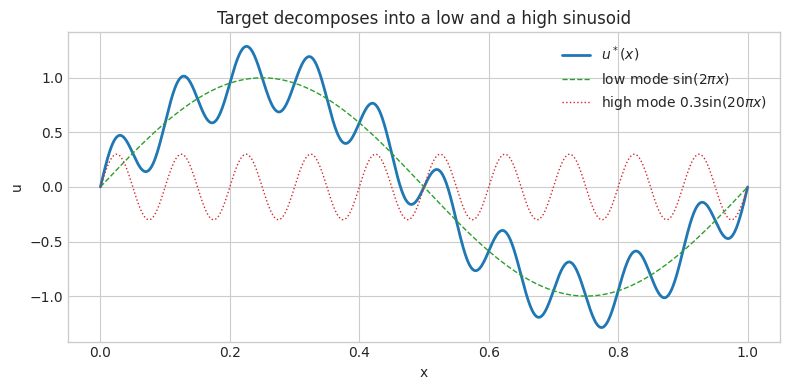

In [2]:
def target_np(x):
    return np.sin(2.0 * np.pi * x) + 0.30 * np.sin(20.0 * np.pi * x)

def target_torch(x):
    return torch.sin(2.0 * torch.pi * x) + 0.30 * torch.sin(20.0 * torch.pi * x)

x_plot = np.linspace(0.0, 1.0, 1000)
plt.figure(figsize=(8, 4))
plt.plot(x_plot, target_np(x_plot), color="tab:blue", linewidth=2, label=r"$u^*(x)$")
plt.plot(x_plot, np.sin(2.0 * np.pi * x_plot), color="tab:green", linewidth=1, linestyle="--", label=r"low mode $\sin(2\pi x)$")
plt.plot(x_plot, 0.30 * np.sin(20.0 * np.pi * x_plot), color="tab:red", linewidth=1, linestyle=":", label=r"high mode $0.3\sin(20\pi x)$")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Target decomposes into a low and a high sinusoid")
plt.legend()
plt.tight_layout()
plt.show()

## Fourier Mode Probe

To *measure* which frequencies a network has learned we compute the sine-Fourier coefficients of the network output on a dense grid,

$$ \hat a_k = 2 \int_0^1 f(x)\,\sin(2\pi k x)\,dx, $$

via the trapezoid rule on $1024$ nodes. For the target above the only non-negligible $\hat a_k$ are $\hat a_1 = 1$ and $\hat a_{10} = 0.30$. Tracking $|\hat a_k^{\text{net}} - \hat a_k^{\text{target}}|$ during training gives a per-mode learning curve, which is the spectral-bias readout.

In [3]:
x_probe = torch.linspace(0.0, 1.0, 1024, dtype=torch.float64)
target_probe = target_torch(x_probe)

mode_ks = [1, 2, 3, 5, 7, 10, 12, 14]

def sine_coeffs(f_vals: torch.Tensor, ks, x: torch.Tensor):
    coeffs = []
    for k in ks:
        basis = torch.sin(2.0 * torch.pi * k * x)
        coeffs.append(2.0 * torch.trapz(f_vals * basis, x))
    return torch.stack(coeffs)

a_target = sine_coeffs(target_probe, mode_ks, x_probe).numpy()
print("target sine coefficients (k:ampie):")
for k, a in zip(mode_ks, a_target):
    print(f"  k={k:>2d}: {a:+.4f}")

target sine coefficients (k:ampie):
  k= 1: +1.0000
  k= 2: -0.0000
  k= 3: +0.0000
  k= 5: +0.0000
  k= 7: -0.0000
  k=10: +0.3000
  k=12: -0.0000
  k=14: -0.0000


## Experiment 1: A Width Sweep Hits an Optimization Ceiling

Universal approximation says a wide enough MLP *can* represent any continuous function. In practice, gradient descent on a fixed-width MLP hits an optimization plateau long before representation fails. We train identical-width MLPs for the same number of steps and look at the final $L^2$ loss. Beyond a certain width the loss barely moves, which is the practical rider on the UAT statement.

width   final MSE   
4       4.297e-02   
8       4.264e-02   
16      4.220e-02   
32      4.222e-02   
64      2.184e-02   
128     4.381e-03   
256     1.184e-02   


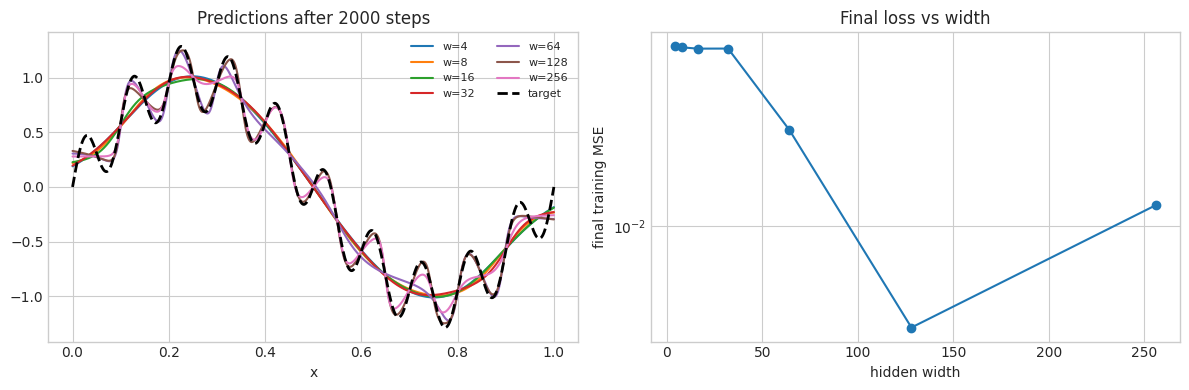

In [4]:
def train_mlp(width, n_iter=2000, lr=2e-2, seed=7):
    torch.manual_seed(seed)
    x_train = torch.linspace(0.0, 1.0, 256).unsqueeze(-1)
    y_train = target_torch(x_train)

    net = nn.Sequential(
        nn.Linear(1, width),
        nn.Tanh(),
        nn.Linear(width, width),
        nn.Tanh(),
        nn.Linear(width, 1),
    )
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(n_iter):
        opt.zero_grad()
        pred = net(x_train)
        loss = ((pred - y_train) ** 2).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        x_e = torch.linspace(0.0, 1.0, 1000).unsqueeze(-1)
        u_e = net(x_e).squeeze()
    opt.zero_grad()
    final_loss = ((net(x_train) - y_train) ** 2).mean().detach().item()
    return net, final_loss, u_e.numpy()

widths = [4, 8, 16, 32, 64, 128, 256]
final_losses = []
final_preds = []
for w in widths:
    net, loss, pred = train_mlp(w)
    final_losses.append(loss)
    final_preds.append(pred)

print(f"{'width':<8}{'final MSE':<12}")
for w, mse in zip(widths, final_losses):
    print(f"{w:<8}{mse:<12.3e}")

x_eval = np.linspace(0.0, 1.0, 1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for w, p in zip(widths, final_preds):
    axes[0].plot(x_eval, p, label=f"w={w}")
axes[0].plot(x_eval, target_np(x_eval), "k--", label="target", linewidth=2)
axes[0].set_title("Predictions after 2000 steps")
axes[0].set_xlabel("x")
axes[0].legend(fontsize=8, ncol=2)
axes[1].semilogy(widths, final_losses, "o-")
axes[1].set_title("Final loss vs width")
axes[1].set_xlabel("hidden width")
axes[1].set_ylabel("final training MSE")
plt.tight_layout()
plt.show()

Two regimes are visible in that table:

- very narrow nets ($w \in \{4, 8, 16\}$) sit near $4 \times 10^{-2}$: they cannot *represent* the high mode well, so the loss floor is fundamentally capacity-limited;
- wider nets ($w \in \{64, 128, 256\}$) drop by one to two orders of magnitude, but then jitter instead of staying monotone: capacity is no longer the binding constraint, training dynamics is.

Even the best width ($w = 128$) only reaches a loss of about $4 \times 10^{-3}$ after 2000 gradient updates. Compare that with the Fourier-features endpoint in Experiment 3, which lands around $10^{-6}$ at the *same* width and the same step count. The gap is not raw capacity; the gap is how the input parameterizes high frequencies. That is the practical meaning of the universal-approximation rider: representable in the limit does not imply *learnable in finite time under plain SGD/Adam*.

## Experiment 2: Reproducing Spectral Bias

Now the key experiment. We train a single width-64 MLP for $3000$ steps and log, every $30$ steps, the per-mode Fourier amplitude error $|\hat a_k^{\text{net}} - \hat a_k^{\text{target}}|$. What we expect, and what Rahaman et al. (2019) observed, is that the error for $k = 1$ drops within tens of steps while the error for $k = 10$ lags by an order of magnitude or more for a long training window. That gap *is* spectral bias.

final MSE: 2.676e-03
final per-mode amplitude error:
  k= 1: 4.421e-04
  k= 2: 1.348e-04
  k= 3: 5.206e-04
  k= 5: 2.474e-03
  k= 7: 6.459e-03
  k=10: 2.550e-02
  k=12: 1.078e-02
  k=14: 7.358e-03


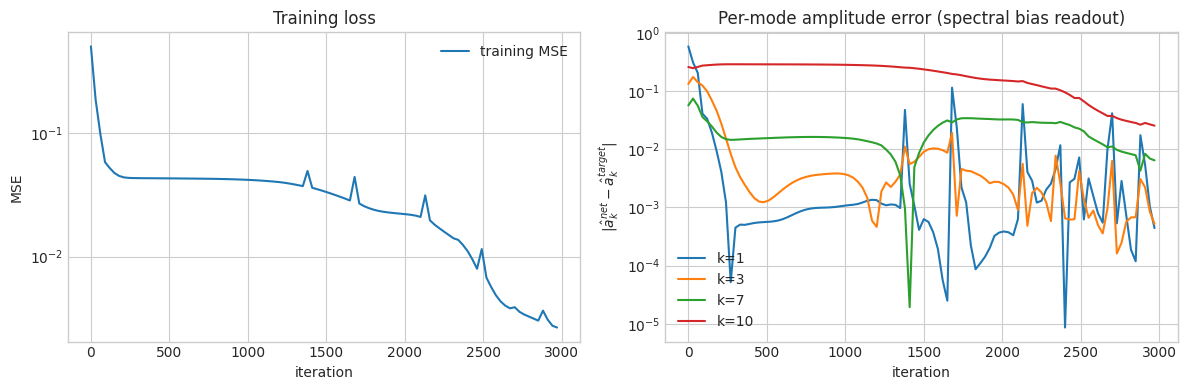

In [5]:
def train_with_mode_log(width=64, n_iter=3000, lr=2e-2, log_every=30, seed=7):
    torch.manual_seed(seed)
    x_train = torch.linspace(0.0, 1.0, 256).unsqueeze(-1).double()
    y_train = target_torch(x_train)

    net = nn.Sequential(
        nn.Linear(1, width).double(),
        nn.Tanh(),
        nn.Linear(width, width).double(),
        nn.Tanh(),
        nn.Linear(width, 1).double(),
    )
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    log_iters = []
    log_loss = []
    log_mode_err = []
    for it in range(n_iter):
        opt.zero_grad()
        pred = net(x_train)
        loss = ((pred - y_train) ** 2).mean()
        loss.backward()
        opt.step()
        if it % log_every == 0:
            with torch.no_grad():
                pred_probe = net(x_probe.unsqueeze(-1)).squeeze()
                a_net = sine_coeffs(pred_probe, mode_ks, x_probe).numpy()
                mode_err = np.abs(a_net - a_target)
            log_iters.append(it)
            log_loss.append(float(loss.detach()))
            log_mode_err.append(mode_err)
    return net, np.array(log_iters), np.array(log_loss), np.array(log_mode_err)

net, log_iters, log_loss, log_mode_err = train_with_mode_log()

print(f"final MSE: {log_loss[-1]:.3e}")
print("final per-mode amplitude error:")
for k, err in zip(mode_ks, log_mode_err[-1]):
    print(f"  k={k:>2d}: {err:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(log_iters, log_loss, color="tab:blue", label="training MSE")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training loss")
axes[0].legend()

for j, k in enumerate(mode_ks):
    if k in (1, 3, 7, 10):
        axes[1].semilogy(log_iters, log_mode_err[:, j], label=f"k={k}")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$|\hat a_k^{net} - \hat a_k^{target}|$")
axes[1].set_title("Per-mode amplitude error (spectral bias readout)")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

The low mode ($k=1$) drops well below the high mode ($k=10$) after the first few hundred steps and stays below for the rest of training. The intermediate modes sit between. Reordering the curves by frequency gives the canonical staircase shape that we will recognise again in multi-scale PINN notebooks.

## Experiment 3: Fourier Feature Encoding Closes the Gap

The standard fix, due to Rahimi & Recht (2007) and popularised for coordinate networks by Tancik et al. (2020), is to replace the raw input $x$ with a fixed random-feature (or deterministic grid) map

$$ \gamma_B(x) = \big(\sin(2\pi B_1 x), \dots, \sin(2\pi B_m x), \cos(2\pi B_1 x), \dots, \cos(2\pi B_m x)\big), $$

where $B$ is a vector of target frequencies. A linear model on $\gamma_B$ can already represent each chosen sinusoid exactly, so an MLP on $\gamma_B$ recovers the high mode at the same rate as the low mode. We repeat the mode-log experiment with the same width and steps, but with $B = \{1, 2, \dots, 12\}$ baked into the input.

In [6]:
def train_fourier_features(B, width=64, n_iter=3000, lr=2e-2, log_every=30, seed=7):
    torch.manual_seed(seed)
    B_t = torch.tensor(B, dtype=torch.float64)
    x_train = torch.linspace(0.0, 1.0, 256).unsqueeze(-1).double()
    y_train = target_torch(x_train)

    def encode(x):
        proj = 2.0 * torch.pi * B_t * x
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    net = nn.Sequential(
        nn.Linear(2 * len(B), width).double(),
        nn.Tanh(),
        nn.Linear(width, width).double(),
        nn.Tanh(),
        nn.Linear(width, 1).double(),
    )
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    log_iters = []
    log_loss = []
    log_mode_err = []
    for it in range(n_iter):
        opt.zero_grad()
        pred = net(encode(x_train))
        loss = ((pred - y_train) ** 2).mean()
        loss.backward()
        opt.step()
        if it % log_every == 0:
            with torch.no_grad():
                pred_probe = net(encode(x_probe.unsqueeze(-1))).squeeze()
                a_net = sine_coeffs(pred_probe, mode_ks, x_probe).numpy()
                mode_err = np.abs(a_net - a_target)
            log_iters.append(it)
            log_loss.append(float(loss.detach()))
            log_mode_err.append(mode_err)
    return net, np.array(log_iters), np.array(log_loss), np.array(log_mode_err)

B_grid = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
net_ff, log_iters_ff, log_loss_ff, log_mode_err_ff = train_fourier_features(B_grid)

print(f"final MSE (Fourier features): {log_loss_ff[-1]:.3e}")
print("final per-mode amplitude error (Fourier features):")
for k, err in zip(mode_ks, log_mode_err_ff[-1]):
    print(f"  k={k:>2d}: {err:.3e}")

final MSE (Fourier features): 1.039e-06
final per-mode amplitude error (Fourier features):
  k= 1: 1.686e-04
  k= 2: 2.365e-04
  k= 3: 4.192e-04
  k= 5: 1.740e-04
  k= 7: 1.092e-04
  k=10: 1.647e-04
  k=12: 1.166e-04
  k=14: 4.300e-05


## Head-to-Head: Vanilla vs Fourier Features

Overlaying the per-mode amplitude errors for the two networks makes the effect compact. Without Fourier features, $k = 10$ sits one to two orders of magnitude above $k = 1$ for most of training. With Fourier features, the two curves move together: high-frequency learning is no longer throttled by the network's intrinsic preference for low modes.

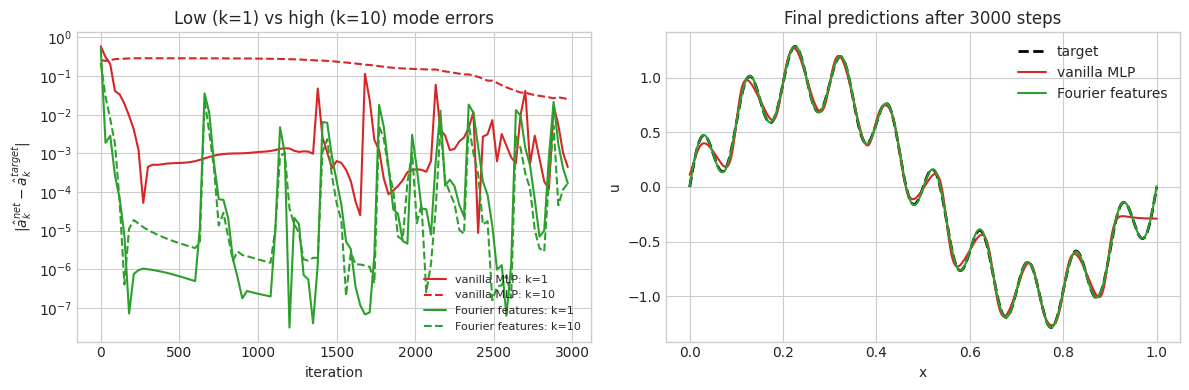

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for net_label, log_err, color in [("vanilla MLP", log_mode_err, "tab:red"), ("Fourier features", log_mode_err_ff, "tab:green")]:
    j_low = mode_ks.index(1)
    j_high = mode_ks.index(10)
    axes[0].semilogy(log_iters, log_err[:, j_low], color=color, label=f"{net_label}: k=1", linestyle="-")
    axes[0].semilogy(log_iters, log_err[:, j_high], color=color, label=f"{net_label}: k=10", linestyle="--")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$|\hat a_k^{net} - \hat a_k^{target}|$")
axes[0].set_title("Low (k=1) vs high (k=10) mode errors")
axes[0].legend(fontsize=8)

x_eval = torch.linspace(0.0, 1.0, 1000).unsqueeze(-1).double()
with torch.no_grad():
    u_van = net(x_eval).squeeze().numpy()
    B_t = torch.tensor(B_grid, dtype=torch.float64)
    def enc(x):
        proj = 2.0 * torch.pi * B_t * x
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
    u_ff = net_ff(enc(x_eval)).squeeze().numpy()
axes[1].plot(x_eval.numpy(), target_np(x_eval.numpy()), "k--", label="target", linewidth=2)
axes[1].plot(x_eval.numpy(), u_van, color="tab:red", label="vanilla MLP")
axes[1].plot(x_eval.numpy(), u_ff, color="tab:green", label="Fourier features")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u")
axes[1].set_title("Final predictions after 3000 steps")
axes[1].legend()
plt.tight_layout()
plt.show()

## Connection to the Rest of the Repo

The Fourier feature fix is the same idea that motivates FNOs (`01_Core_Path/09_fourier_neural_operator.ipynb`): if the bottleneck is high-frequency learning, let the model operate *in* a spectral basis rather than fight uphill in physical space. Concretely:

- `01_Core_Path/06_multi_scale_pinns.ipynb` extends spectral bias from this toy regression problem to PINN residuals, where the residual lives on whichever frequencies the PDE forces.
- `01_Core_Path/05_residual_based_adaptive_sampling.ipynb` can be read as a sampling-side analogue of Fourier features: spend collocation effort where the network still has high-frequency error.
- `05_inverse_and_discovery/*` will inherit this spectrum-vs-rate trade-off implicitly, because discovered equations inherit the network's mode preference.

The narrow message is durable: universal approximation does not imply fast approximation.

## Key Takeaways

- Universal approximation is an *existence* statement; the width sweep shows that finite-time Adam stops improving the fit far before representation power runs out.
- Per-frequency Fourier probing during training reproduces spectral bias visibly: $k = 1$ converges one to two orders of magnitude faster than $k = 10$.
- A deterministic Fourier feature encoding $\gamma_B$ restores the rate parity for the chosen frequencies, which is the same trick classical kernel methods (Rahimi & Recht, 2007) and modern coordinate MLPs (Tancik et al., 2020) rely on.
- This single lens (low-frequency first, Fourier features as a structural fix) explains enough of PINN and operator-learning behaviour that we treat it as a stable reference for the rest of the repo.

## References

- Cybenko, G. *Approximation by Superpositions of a Sigmoidal Function*. Mathematics of Control, Signals, and Systems, 1989.
- Hornik, K. *Approximation Capabilities of Multilayer Feedforward Networks*. Neural Networks, 1991.
- Rahaman, N. et al. *On the Spectral Bias of Neural Networks*. ICML, 2019.
- Ronen, B. et al. *The Convergence Rate of Neural Networks for Mapped Functions*. NeurIPS Warm-Up, 2019.
- Rahimi, A.; Recht, B. *Random Features for Large-Scale Kernel Machines*. NeurIPS, 2007.
- Tancik, M. et al. *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains*. NeurIPS, 2020.
- Wang, S.; Yu, X.; Perdikaris, P. *When and Why PINNs Fail to Train*. JCP, 2022.